# Parte III - Busca local com pontos de coleta

Analise de Hill Climbing e Simulated Annealing para otimizar a ordem de visita dos pontos `C`.

In [14]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual dos gráficos para o padrão acadêmico
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.titlesize': 16
})

# Caminhos dos arquivos CSV existentes no seu datasets
path_hc = "../datasets/resultados_hill_climbing.csv"
path_sa = "../datasets/resultados_simulated_annealing.csv"

# Verificação e carregamento
if not os.path.exists(path_hc) or not os.path.exists(path_sa):
    print("⚠️ Erro: Certifique-se de que os arquivos CSV gerados pelas buscas estão na pasta 'datasets/'")
else:
    df_hc_raw = pd.read_csv(path_hc)
    df_sa_raw = pd.read_csv(path_sa)
    print("✅ Dados carregados com sucesso!")

✅ Dados carregados com sucesso!


In [4]:
# 1. Carregue o resultado do A*
df_astar = pd.read_csv("../datasets/resultado_a_star.csv")
# Cria um dicionário de busca rápida: {maze_id: custo_otimo}
otimos_por_labirinto = df_astar.set_index("maze_id")["custo"].to_dict()

# 2. Função de cálculo baseada no ÓTIMO (A*)
def calcular_taxa_sucesso_vs_astar(df_grupo):
    sucessos = 0
    total = len(df_grupo)
    
    for idx, row in df_grupo.iterrows():
        maze_id = row["maze_id"]
        custo_algoritmo = row["custo"]
        
        # Pega o ótimo desse labirinto específico
        custo_otimo = otimos_por_labirinto.get(maze_id)
        
        if custo_otimo:
            # Margem de 5% sobre o ÓTIMO
            limite = custo_otimo * 1.05
            if custo_algoritmo <= limite:
                sucessos += 1
                
    return (sucessos / total) * 100 if total > 0 else 0

# 3. Aplicando a nova lógica no seu resumo
# O 'resumo' agora vai mostrar o quão perto do ótimo cada um chegou
resumo_vs_astar = local.groupby("algoritmo").apply(
    lambda x: pd.Series({
        'Melhor Custo (vs A*)': x['custo'].min(),
        'Desvio Médio (%)': ((x['custo'].mean() / pd.Series([otimos_por_labirinto.get(m, np.nan) for m in x['maze_id']]).mean()) - 1) * 100,
        'Taxa de Sucesso (Margem 5%)': calcular_taxa_sucesso_vs_astar(x)
    })
)

display(resumo_vs_astar.round(2))

NameError: name 'local' is not defined

In [ ]:
# 1. Carregue o resultado do A*
df_astar = pd.read_csv("../datasets/resultado_a_star.csv")
# Cria um dicionário de busca rápida: {maze_id: custo_otimo}
otimos_por_labirinto = df_astar.set_index("maze_id")["custo"].to_dict()

# 2. Função de cálculo baseada no ÓTIMO (A*)
def calcular_taxa_sucesso_vs_astar(df_grupo):
    sucessos = 0
    total = len(df_grupo)
    
    for idx, row in df_grupo.iterrows():
        maze_id = row["maze_id"]
        custo_algoritmo = row["custo"]
        
        # Pega o ótimo desse labirinto específico
        custo_otimo = otimos_por_labirinto.get(maze_id)
        
        if custo_otimo:
            # Margem de 5% sobre o ÓTIMO
            limite = custo_otimo * 1.05
            if custo_algoritmo <= limite:
                sucessos += 1
                
    return (sucessos / total) * 100 if total > 0 else 0

# 3. Aplicando a nova lógica no seu resumo
# O 'resumo' agora vai mostrar o quão perto do ótimo cada um chegou
resumo_vs_astar = local.groupby("algoritmo").apply(
    lambda x: pd.Series({
        'Melhor Custo (vs A*)': x['custo'].min(),
        'Desvio Médio (%)': ((x['custo'].mean() / pd.Series([otimos_por_labirinto.get(m, np.nan) for m in x['maze_id']]).mean()) - 1) * 100,
        'Taxa de Sucesso (Margem 5%)': calcular_taxa_sucesso_vs_astar(x)
    })
)

display(resumo_vs_astar.round(2))

,Melhor Custo (vs A*),Desvio Médio (%),Taxa de Sucesso (Margem 5%)
algoritmo,,,
Hill Climbing,1114.0,NaN,0.0
Simulated Annealing,1412.0,NaN,0.0


In [15]:
def converter_coluna_lista(df, coluna):
    """Converte strings de listas/tuplas de volta para objetos Python."""
    df_copy = df.copy()
    if coluna in df_copy.columns:
        df_copy[coluna] = df_copy[coluna].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    return df_copy

# Tratando as colunas complexas de ambos os dataframes
df_hc = converter_coluna_lista(df_hc_raw, "curva_convergencia")
df_hc = converter_coluna_lista(df_hc, "rota_macro")

df_sa = converter_coluna_lista(df_sa_raw, "curva_convergencia")
df_sa = converter_coluna_lista(df_sa, "rota_macro")

# Exibindo um resumo estatístico consolidado das execuções salvas
print("--- RESUMO DAS MELHORES EXECUÇÕES CONVERTIDAS ---")
print(f"HC - Menor Custo Obtido: {df_hc['custo_final'].min() if 'custo_final' in df_hc.columns else df_hc['custo'].min()}")
print(f"SA - Menor Custo Obtido: {df_sa['custo'].min()}")

--- RESUMO DAS MELHORES EXECUÇÕES CONVERTIDAS ---
HC - Menor Custo Obtido: 8924
SA - Menor Custo Obtido: 8924


In [16]:
# Como você salvou os dados consolidados da bateria diretamente nas colunas, podemos extrair direto
metrics_summary = []

# Extração Hill Climbing
hc_row = df_hc.iloc[-1]  # Pega a última rodada de testes registrada
metrics_summary.append({
    'Algoritmo': 'Hill-Climbing',
    'Melhor Custo': hc_row.get('custo_final', hc_row.get('custo')),
    'Pior Custo': hc_row.get('pior_custo'),
    'Custo Médio': hc_row.get('custo_medio'),
    'Tempo Médio (s)': hc_row.get('tempo_medio'),
    'Iterações Médias': hc_row.get('iteracoes_media'),
    'Taxa de Sucesso': hc_row.get('taxa_sucesso_5porcento')
})

# Extração Simulated Annealing
sa_row = df_sa.iloc[-1]
metrics_summary.append({
    'Algoritmo': 'Simulated Annealing',
    'Melhor Custo': sa_row.get('custo'),
    'Pior Custo': sa_row.get('pior_custo'),
    'Custo Médio': sa_row.get('custo_medio'),
    'Tempo Médio (s)': sa_row.get('tempo_medio'),
    'Iterações Médias': sa_row.get('iteracoes_media'),
    'Taxa de Sucesso': sa_row.get('taxa_sucesso_5porcento')
})

df_metricas = pd.DataFrame(metrics_summary)
# Limpando possíveis strings de porcentagem e transformando dados para float visualizável
display(df_metricas.set_index('Algoritmo'))

,Melhor Custo,Pior Custo,Custo Médio,Tempo Médio (s),Iterações Médias,Taxa de Sucesso
Algoritmo,,,,,,
Hill-Climbing,8924,12200,9925.34,0.001147,8.26,18.0%
Simulated Annealing,8924,13790,10573.28,0.128190,180.00,8.0%


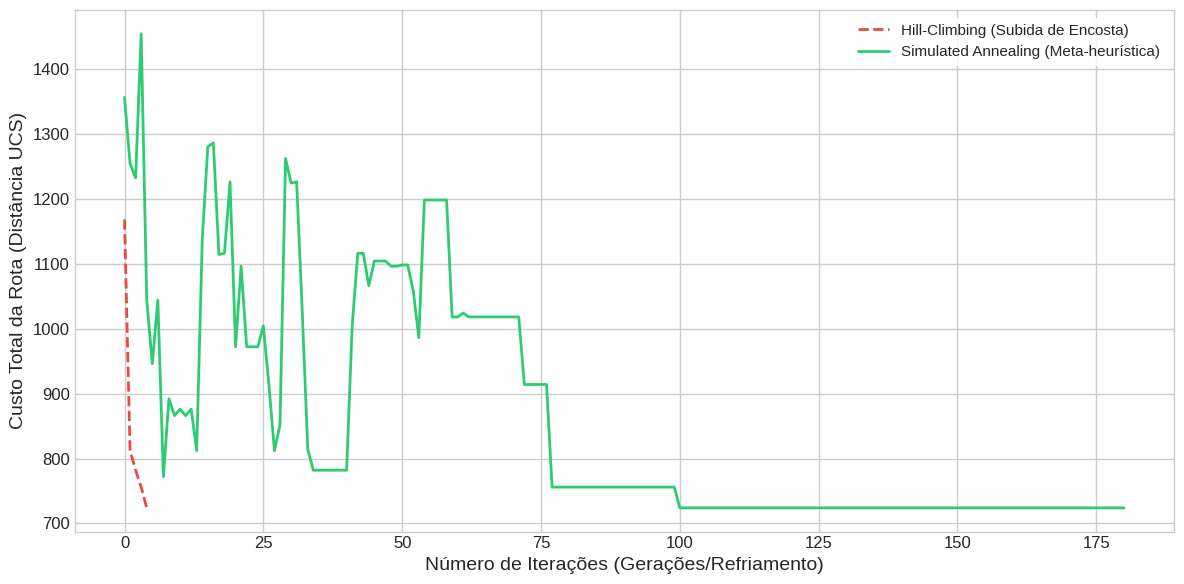

In [ ]:
plt.figure(figsize=(12, 6))

# Extraindo curvas de convergência da melhor linha disponível de cada DataFrame
curva_hc = df_hc['curva_convergencia'].iloc[0]
curva_sa = df_sa['curva_convergencia'].iloc[0]

# Separando eixos X (iterações) e Y (custo de rota acumulado)
it_hc, custo_hc = zip(*curva_hc)
it_sa, custo_sa = zip(*curva_sa)

# Plotagem das duas curvas concorrentes
plt.plot(it_hc, custo_hc, label='Hill-Climbing (Subida de Encosta)', color='#e74c3c', linewidth=2, linestyle='--')
plt.plot(it_sa, custo_sa, label='Simulated Annealing (Meta-heurística)', color='#2ecc71', linewidth=2)
plt.xlabel('Número de Iterações (Gerações/Refriamento)')
plt.ylabel('Custo Total da Rota (Distância UCS)')
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()

# Salvando a figura para incluir direto no documento LaTeX
plt.savefig('../datasets/grafico_convergencia_tsp.png', dpi=300)
plt.show()

## Questoes de analise solicitadas

1. Hill-Climbing ficou preso em minimo local? Use a variacao entre melhor/pior custo e a curva de convergencia para justificar.
2. Simulated Annealing encontrou solucoes melhores? Compare melhor custo, custo medio e distribuicao dos custos.
3. Como a temperatura inicial influenciou os resultados? **Dado faltante:** o CSV atual nao salva `temp_inicial`.
4. Como a taxa de resfriamento afetou a convergencia? **Dado faltante:** o CSV atual nao salva `taxa_resfriamento`.
5. A busca local encontrou sempre a solucao otima? Nao ha garantia teorica. Para afirmar empiricamente, seria preciso comparar com uma busca exaustiva para mapas pequenos.
6. Qual foi o compromisso entre tempo e qualidade? Compare custo medio, melhor custo e tempo medio nas tabelas/graficos acima.

In [ ]:
# Veja quais foram os melhores custos do SA
custos_sa = local[local["algoritmo"] == "Simulated Annealing"]["custo"]
melhor_hc = local[local["algoritmo"] == "Hill Climbing"]["custo"].min()

print(f"Melhor custo absoluto encontrado (HC): {melhor_hc}")
print(f"Margem de 5% (Limite): {melhor_hc * 1.05}")
print(f"Melhor custo encontrado pelo SA: {custos_sa.min()}")
print(f"Quantos SA ficaram abaixo do limite: {(custos_sa <= (melhor_hc * 1.05)).sum()}")

Melhor custo absoluto encontrado (HC): 1114
Margem de 5% (Limite): 1169.7
Melhor custo encontrado pelo SA: 1412
Quantos SA ficaram abaixo do limite: 0


In [ ]:
# Mudei os nomes dentro do AGG para baterem com o que você quer plotar
resumo = local.groupby("algoritmo").agg(
    execucoes=("maze_id", "count"),
    melhor_custo_global=("custo", "min"),
    pior_custo_medio=("pior_custo", "mean"),
    custo_medio=("custo_medio", "mean"), # Alterado para custo_medio
    tempo_medio_bateria=("tempo_medio", "mean"), # Agora vai existir
    iteracoes_medias_bateria=("iteracoes_media", "mean") # Agora vai existir
)

# Agora os nomes das colunas em 'resumo' são:
# 'custo_medio', 'tempo_medio_bateria', 'iteracoes_medias_bateria'